# 6. The Laplacian Pyramid


In [1]:
%matplotlib widget
import warnings
import inspect
import matplotlib.pyplot as plt
import IPython.display
import numpy as np
from cued_sf2_lab.familiarisation import load_mat_img, plot_image

## 6.1 The basic concept


<figure id="figure-2">
<div style="background-color: white">

![](figures/laplacian.svg)</div>

<figcaption style="text-align: center">Figure 2: A typical laplacian pyramid with 2 levels; forward (analysis) part only</figcaption>
</figure>


### Core Concepts

At level $k$:

- $X_k$ — lowpass image _entering_ the level. $X_0 = X$ is the original.
- $X_{k+1}$ — quarter-size lowpass image _leaving_ the level (passed to the next level).
- $\hat{X}_k$ — full-size _prediction_ of $X_k$ rebuilt from $X_{k+1}$ alone (blurred — high frequencies are lost in decimation).
- $Y_k = X_k - \hat{X}_k$ — the _residual_ (Laplacian/bandpass layer): the detail $\hat{X}_k$ couldn't predict.

Only the residuals $Y_0, Y_1, \dots, Y_{L-1}$ are stored, and the tiny lowpass $X_L$. The $\hat{X}_k$'s are never stored as the decoder regenerates them

**Operators.** $h$ is a separable lowpass filter with unity DC gain; $D$ is 2:1 decimation; $U$ is 2:1 zero-insertion upsampling. Filtering is applied separably (rows then columns — exactly `rowdec`/`rowint` applied via a transpose).

**Encoder.** For $k = 0, 1, \dots, L-1$:

$$
\begin{aligned}
X_{k+1} &= D(\,h * X_k\,)         &&\text{lowpass + decimate}\\
\hat{X}_k &= (2h) * U(X_{k+1})    &&\text{upsample + interpolate to full size}\\
Y_k &= X_k - \hat{X}_k            &&\text{residual stored at this level}
\end{aligned}
$$

**Decoder.** Start from $Z_L = X_L$ and walk back down:

$$
Z_k = (2h) * U(Z_{k+1}) + Y_k.
$$

The first term reconstructs $\hat{X}_k$ on the fly; adding $Y_k$ recovers $X_k$ exactly (induction: $Z_{k+1} = X_{k+1} \Rightarrow Z_k = X_k$), so $Z_0 = X$.

**Why $2h$ on interpolation.** Zero-insertion halves the DC gain, so doubling $h$ restores it: $\sum_n 2h[n]\,[U(x)][n] = \sum_n h[n]\,x[n]$. This makes $\hat{X}_k$ have the same brightness as $X_k$.

**Sample-count overhead.** Each $Y_k$ is a quarter the size of $Y_{k-1}$, so total samples sum to

$$
N\bigl(1 + \tfrac{1}{4} + \tfrac{1}{16} + \dots\bigr) \;\xrightarrow{L \to \infty}\; \tfrac{4}{3}N,
$$

i.e. at most a 33% sample overhead — easily recovered by the much lower entropy of the $Y_k$.


The Laplacian pyramid is an energy compaction technique, based on
the observation:

> For most real-world images, the high-frequency energy is much less than the low-frequency energy.

Since the lowpass image is much lower bandwidth than the
original image, it can be subsampled (_decimated_) 2:1 in both
horizontal and vertical directions, without significant loss of
information to give a quarter-size lowpass image. We have
provided a row filter/decimation function, `rowdec(X, h)`, to
filter and decimate the rows of a matrix by 2:1.


### Decimation with `rowdec`


In [2]:
from cued_sf2_lab.laplacian_pyramid import rowdec
from cued_sf2_lab.laplacian_pyramid import rowint

Use this twice
(on the image and its transpose) to generate a quarter-size
lowpass image `X1` of Lighthouse. For simplicity use a 3-tap (length 3)
filter `h` with coefficients: $\frac{1}{4} [1\ 2\ 1]$.


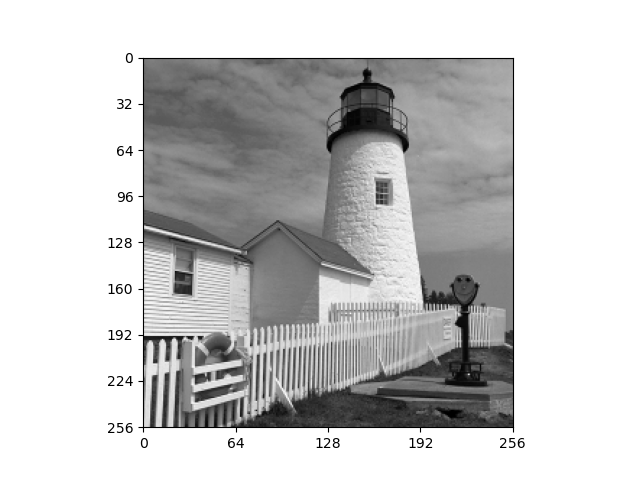

In [3]:
X0, cmaps_dict = load_mat_img(img='lighthouse.mat', img_info='X', cmap_info={'map', 'map2'})
fig, ax = plt.subplots()
plot_image(X0, ax=ax);

In [4]:
#define simple filter
h = 0.25*np.array([1, 2, 1])

### Interpolation with `rowint`


The image `X1` can be interpolated 2:1 in each direction to
generate a lowpass image of the original size, which can then be
subtracted from the original to yield a full-size highpass image.
We have also provided a row interpolation/filter function,
`rowint(X, h)`, which doubles the length of each row of the image, by
inserting zeros between alternate samples and then lowpass
filtering the result with the filter `h`. Note that to undo the decimation
performed by `Y = rowdec(X, h)`, this should be called as `Z = rowint(Y, 2*h)`,
where a DC gain of 2 is added, as shown in [Figure 2](#figure-2).


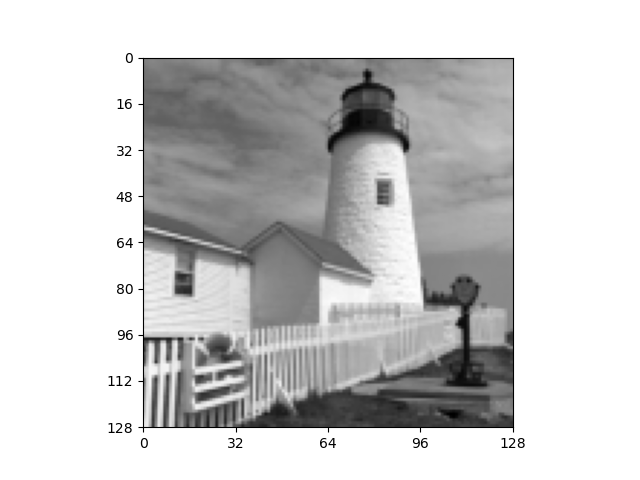

In [5]:
#row filter, then col filter
# need 2D convolution for subsampling to be correct!
X1 = rowdec(rowdec(X0,h).T,h).T
fig, ax = plt.subplots()
plot_image(X1, ax=ax);

Apply this twice (as before) to generate
a full-size lowpass image, and subtract this from `X` to
give a highpass image `Y0`. Display `X1` and `Y0` to see these effects.


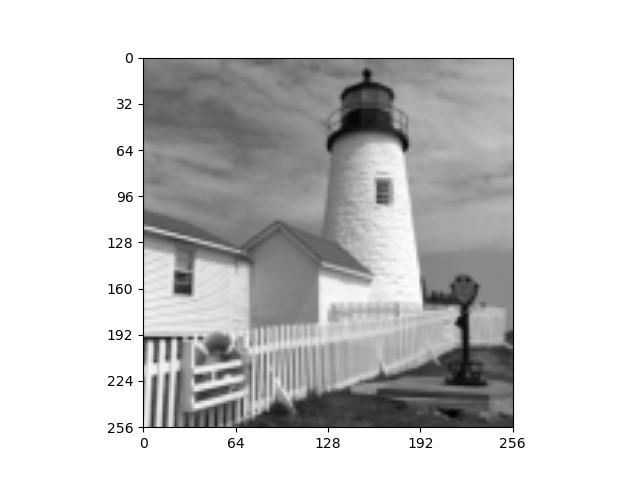

In [6]:
X0_hat = rowint(rowint(X1, 2*h).T, 2*h).T
fig, ax = plt.subplots()
plot_image(X0_hat, ax=ax);

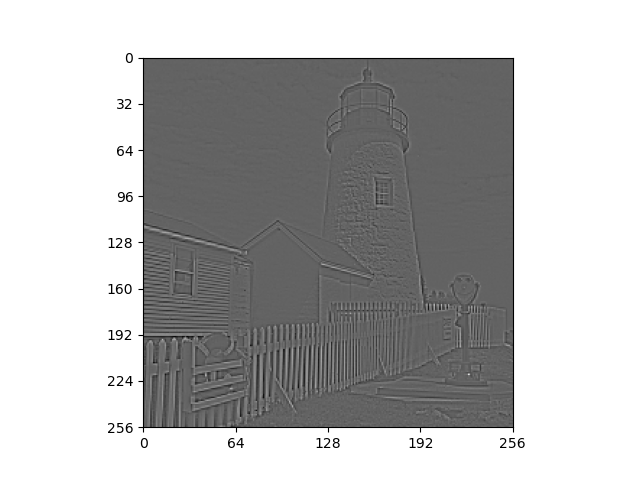

In [7]:
Y0 = X0-X0_hat
fig, ax = plt.subplots()
plot_image(Y0, ax=ax);

The highpass images will
always have approximately zero mean (since any dc component is
removed). Hence for the remainder of this project, we recommend
that you also make all lowpass images be approximately zero mean
by subtracting 128 from them before you start any processing. This
makes the 8-bit pixel values cover the range -128 to 127,
instead of 0 to 255. The advantages of having a zero-mean input image are not very obvious here, but they
will become clearer as the project progresses. If you use `draw_image` the images will still be displayed correctly.


In [8]:
X, cmaps_dict = load_mat_img(img='lighthouse.mat', img_info='X', cmap_info={'map', 'map2'})
X = X - 128.0

Examine the functions `rowdec` and `rowint` and check that you understand how they work. Decimation is achieved by selecting every second element of a vector using selection indices `i:i+c:2`, and filtering is performed with symmetric extension as in `convse`, except that we do not bother to calculate the filter outputs that are to be discarded by the decimation process. Interpolation is achieved by loading every second element of a double-size vector using `X2 = np.zeros((r, c2), dtype=X.dtype)`, `X2[:, ::2] = X`. The intermediate samples of the interpolated vector x must be zero before the vector is passed through the interpolation filter.


### Building the pyramid encoder


In [9]:
#IPython.display.Code(inspect.getsource(rowdec), language="python")

In [10]:
#IPython.display.Code(inspect.getsource(rowint), language="python")

If the small lowpass image `X1` and the full-size highpass image `Y0`
are transmitted to a distant decoder, then the decoder can exactly reconstruct
the original image by interpolating `X1` up to full size and adding in
`Y0` (which represents the error between the original and the interpolated
`X1`). We have achieved image compression if `X1` and `Y0` can be
transmitted with fewer bits than `X`. Usually this will be the case
because `Y0` contains so much less energy than `X`, and `X1` is
only one quarter of the size of `X`. However we do start at a
disadvantage because there are 25% more samples to code. Many of the `Y0` samples may be represented by zero, and we shall show later that runs of
zeros may be coded with relatively few bits.

The quarter-size lowpass image `X1` may be further subsampled, using the
same process as was applied to `X`, so that it may be transmitted as a
one-sixteenth-size lowpass image `X2` and a quarter-size highpass image
`Y1`. This usually achieves further data compression and may be repeated
as many times as is desired (until, for typical images, no further compression
is achieved). This leads to a pyramid of highpass images and a final tiny
lowpass image. Usually three or four layers of the pyramid are sufficient to
give maximum compression.

Write a `py4enc(X, h)` function to generate a 4-layer pyramid, so that `X` is split into four
highpass images, `Y0 Y1 Y2 Y3`, each a quarter of the size of its predecessor, plus a tiny
lowpass image `X4`, which is a quarter of the size of `Y3`.


In [11]:
def py4enc(X, h):
    # row first, then column wise
    X1 = rowdec(rowdec(X, h).T, h).T
    X0_hat = rowint(rowint(X1, 2*h).T, 2*h).T
    Y0 = X - X0_hat

    X2 = rowdec(rowdec(X1, h).T, h).T
    X1_hat = rowint(rowint(X2, 2*h).T, 2*h).T
    Y1 = X1 - X1_hat

    X3 = rowdec(rowdec(X2, h).T, h).T
    X2_hat = rowint(rowint(X3, 2*h).T, 2*h).T
    Y2 = X2 - X2_hat

    X4 = rowdec(rowdec(X3, h).T, h).T
    X3_hat = rowint(rowint(X4, 2*h).T, 2*h).T
    Y3 = X3 - X3_hat

    return Y0, Y1, Y2, Y3, X4

The general `k`-layer version, `pykenc(X, h, k)`, iterates the same step so it works for any depth


In [12]:
def pykenc(X, h, k):
    """k-layer Laplacian pyramid encoder.
    Returns (Ys, Xk) where Ys = [Y_0, ..., Y_{k-1}] and Xk is the tiny lowpass."""
    Ys = []
    Xk = X
    for _ in range(k):
        Xk_next = rowdec(rowdec(Xk, h).T, h).T
        Xk_hat  = rowint(rowint(Xk_next, 2*h).T, 2*h).T
        Ys.append(Xk - Xk_hat)
        Xk = Xk_next
    return Ys, Xk


We can then plot the results to check them using the `beside` helper function:


In [13]:
from cued_sf2_lab.laplacian_pyramid import beside

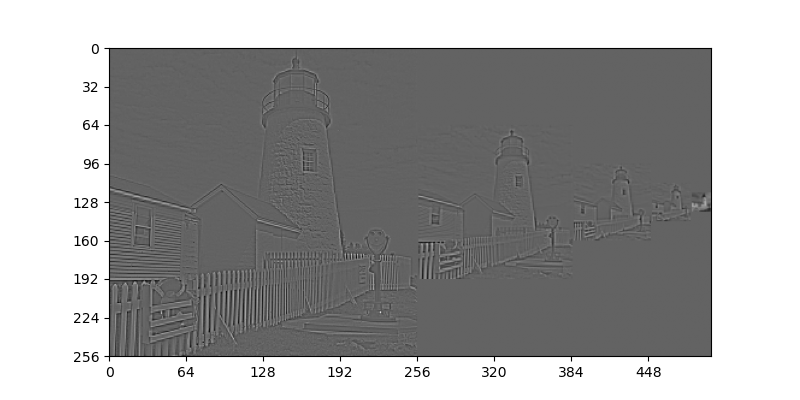

In [14]:
Ys, X4 = pykenc(X, h, 4)
Y0, Y1, Y2, Y3 = Ys
fig, ax = plt.subplots(figsize=(8, 4))
plot_image(beside(Y0, beside(Y1, beside(Y2, beside(Y3, X4)))), ax=ax);

If we wish to see the images separately from each other, instead of using our `beside` function that was written to match the old Matlab version, we can draw this directly with `matplotlib` using [`plt.subplots`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html) to create a set of subplots, and the `width_ratios` argument to [`GridSpec`](https://matplotlib.org/stable/api/_as_gen/matplotlib.gridspec.GridSpec.html):


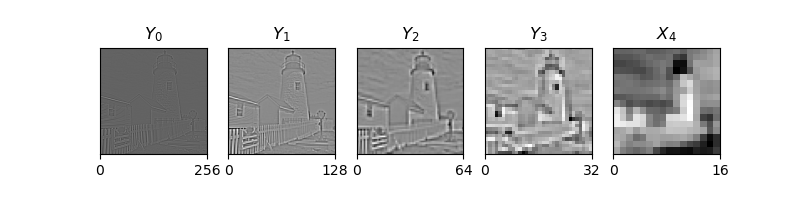

In [15]:
titles = ["Y_0", "Y_1", "Y_2", "Y_3", "X_4"]
imgs = [Y0, Y1, Y2, Y3, X4]
# Equal-width panels; tick labels reveal each sub-image's native size.
fig, axs = plt.subplots(1, 5, figsize=(8, 2))

for ax, img, title in zip(axs, imgs, titles):
    plot_image(img, ax=ax)
    ax.set(yticks=[], title=f'${title}$')
fig.savefig('zach/images/pyramid_montage.png', dpi=150, bbox_inches='tight')

### Decoding the pyramid


Get a demonstrator to check that your images look correct, and
then write another function `py4dec` to decode `X4` and
`Y3 Y2 Y1 Y0` into a set of lowpass images `Z3 Z2 Z1 Z0`.
(`Z3` is obtained by interpolating `X4` and adding
`Y3`, and then `Z2` is obtained from `Z3` and `Y2`, and
so on.)


In [16]:
def py4dec(Y0, Y1, Y2, Y3, X4, h):

    Z3 = rowint(rowint(X4, 2*h).T, 2*h).T + Y3
    Z2 = rowint(rowint(Z3, 2*h).T, 2*h).T + Y2
    Z1 = rowint(rowint(Z2, 2*h).T, 2*h).T + Y1
    Z0 = rowint(rowint(Z1, 2*h).T, 2*h).T + Y0

    return Z3, Z2, Z1, Z0

The general `k`-layer version, `pykdec(Ys, Xk, h)`, walks back up the pyramid for any depth:


In [17]:
def pykdec(Ys, Xk, h):
    """k-layer Laplacian pyramid decoder. Inverse of pykenc.
    Returns Zs = [Z_{k-1}, Z_{k-2}, ..., Z_0]; Z_0 reconstructs the input."""
    Zs = []
    Z = Xk
    for Y in reversed(Ys):
        Z = rowint(rowint(Z, 2*h).T, 2*h).T + Y
        Zs.append(Z)
    return Zs

If all is correct, `Z0` should be identical to
`X`. You can check that your function is correct by calculating `np.max(abs(X - Z0))` and also displaying your pyramid of decoded images, `Z3` to `Z0`.


Encode-Decode Error = 0.0


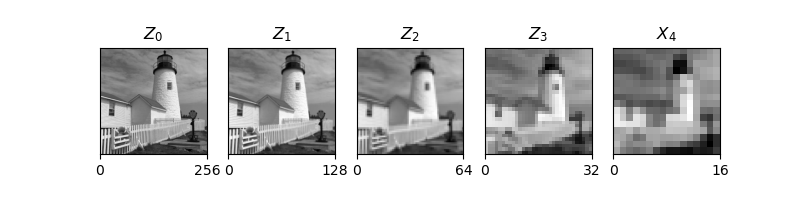

In [18]:
Zs = pykdec(Ys, X4, h)
Z3, Z2, Z1, Z0 = Zs
encode_decode_err = np.max(np.abs(X - Z0))
print(f'Encode-Decode Error = {encode_decode_err}')

# Ordered largest -> smallest, equal-width panels (tick labels show native sizes)
# so the row visually mirrors the Y-row montage in cell-31.
titles = ["Z_0", "Z_1", "Z_2", "Z_3", "X_4"]
imgs = [Z0, Z1, Z2, Z3, X4]
fig, axs = plt.subplots(1, 5, figsize=(8, 2))

for ax, img, title in zip(axs, imgs, titles):
    plot_image(img, ax=ax)
    ax.set(yticks=[], title=f'${title}$')
fig.savefig('zach/images/recon_montage.png', dpi=150, bbox_inches='tight')

For further information on the Laplacian Pyramid see Burt and Adelson [IEEE Trans. on Communications, 1983, vol 31, no 4, pp 532-540, "The Laplacian Pyramid as a compact image code"].


## 6.2 Quantisation and Coding Efficiency

To see whether data compression is possible using the above pyramid decomposition, we must calculate the approximate number of bits required to code the image pyramid. This may be done using the _entropy_ of the quantised image data.

The entropy of a single data sample, whcih may randomly take one of $Q$ possible quantised values such that each value $q(i)$ has a probability $p(i)$ of being in state $i$ for $i=1\to Q$ is given by:

$$ \text{Entropy (bits/sample)} = \sum*{i=1}^Qp(i) \log_2\frac{1}{p(i)} = -\sum*{i=1}^Q p(i) \log_2p(i)$$

The entropy represents the minimum average number of bits per sample needed to code samples with the given probability distribution $p(i)$, assuming that an ideal variable-length entropy code is used, and that the samples are uncorrelated with each other. Arithmetic codes can get arbitrarily close to this bit rate, and simpler Huffman codes can also get vary close with many typical signals (you will be using Huffman codes later on). It is possible to code signals at bit rates less than the entropy, if the samples are correlated, but for simplicity we shall ignore this here.

To demonstrate the validity of the above formula, first consider a signal with 8 quantised values of equal probability $p(i) = 1/8$ for all $i$. The entropy is then $8 \times 1/8 \times \log_2(8) = 3$ bits per sample, as expected.

Now consider a signal with only 3 values, with probabilities $p(1)=1/2$, $p(2) = p(3) = 1/4$. The entropy is then $\frac{1}{2} \log_2(2) + 2 \times \frac{1}{4} \log_2(4) = 1.5$ bits per sample. This is consistent with using a single bit '0' to represent state 1 and two bits, '10' and '11' to represent states 2 and 3.

The function `bpp` has been written to calculate the entropy in bits per pixel of an image matrix `X`. First the function computes a histogram of `X` to determine the probabilities $p(i)$ and then it calculates the entropy, using the above formula.


In [19]:
from cued_sf2_lab.laplacian_pyramid import bpp

In the Laplacian Pyramid, the total number of bits is obtained by multiplying each of the sub-image entropies by the number of pixels in each corresponding sub-image. This gives us the average number of bits used per image (group of pixels)

However, in order to compress the data, we also need to quantise the images. We have also provided a function `quantise` which will quantise `X` in steps centred on integer multiples of `step`. Hence `bpp(quantise(X, step))` will return the entropy of image `X` quantised in steps of `step`.


In [20]:
from cued_sf2_lab.laplacian_pyramid import quantise

### Entropy of the quantised pyramid


<div class="alert alert-block alert-danger">

Calculate the entropies of images `X` `X1` `Y0` and hence the total numbers of bits to encode `X`, or `X1` and `Y0`, when quantised to a step size of 17 (which gives 15 distict grey levels if applied to a lowpass image with intensities from -127 to 127. Find the data compression for this simple one-stage pyramid, and then investigate the improvements from using more layers.

</div>


In [21]:
#quantization width
step = 17

In [22]:
#num bits for the original quantized image
# Total bits = entropy × number of pixels per subband.
H_X = bpp(quantise(X, step))
bits_direct = H_X * X.size
print(f'Direct: H_X = {H_X} bpp,  total = {bits_direct} bits')

Direct: H_X = 3.480820259379386 bpp,  total = 228119.03651868744 bits


In [23]:
# Compression ratio = direct-quantisation bits / pyramid bits.

for k in (1, 2, 3, 4, 5):
    Ys, Xk = pykenc(X, h, k)
    bits = sum(
          #sum all the total num bits for all the Ys
          bpp(quantise(Y, step)) * Y.size for Y in Ys) \
         + bpp(quantise(Xk, step)) * Xk.size #sum the final X too
    print(f'k={k}: total = {bits} bits,  CR = {bits_direct/bits}')

k=1: total = 162152.8723186979 bits,  CR = 1.406814651240581
k=2: total = 142641.49877817277 bits,  CR = 1.599247333158242
k=3: total = 138263.47687483625 bits,  CR = 1.6498864463331369
k=4: total = 137353.14037048537 bits,  CR = 1.6608214118976632
k=5: total = 137247.1057082155 bits,  CR = 1.662104532853784


### RMS error of the reconstruction


Since compressing an image will generally result in a reduction in quality, we also need a way to measure this quality reduction. It is actually quite hard to find a quality measure whcih matches individual perceptions of how an image has been changed due to compression, and for that reason it is important to always judge and comment on an image visually. However we also need a quantitative measure, and the most obvious is the rms error (standard deviation) between the input and compressed image (i.e. using `np.std(X - Z)` where `Z` is the compressed image).

<div class="alert alert-block alert-danger">
Quantise the Laplacian pyramid with a step size of 17, and reconstruct the output image from the decoding pyramid. Look at the visual features, and calculate the rms error (standard deviation) between the input image and the decoding pyramid output image. Repeat this for more layers in the pyramid.
</div>


Direct quantisation: RMS = 4.861168497356846


[Text(0.5, 1.0, 'Direct quantise image, step=17')]

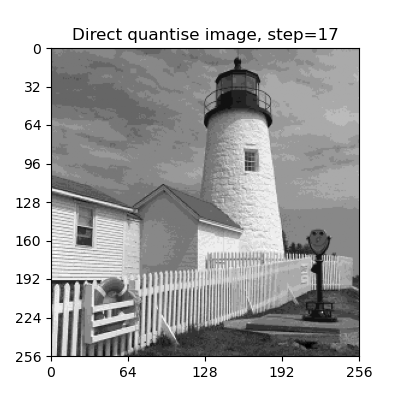

In [24]:
X_q = quantise(X, step)
rms_direct = np.std(X - X_q)
print(f'Direct quantisation: RMS = {rms_direct}')

fig, ax = plt.subplots(figsize=(4, 4))
plot_image(X_q, ax=ax)
ax.set(title=f'Direct quantise image, step={step}')

In [25]:
#reconstruct X with pyramid scheme; returns (Z0_q, rms, bits)
def pyr_quantize_layered(X, steps, k, h):
    """Each layer has a different quantization step
    `steps` has length k+1, ordered [Y_0, ..., Y_{k-1}, X_k]."""
    Ys, Xk = pykenc(X, h, k)
    Ys_q = [quantise(Y, s) for Y, s in zip(Ys, steps[:-1])]
    Xk_q = quantise(Xk, steps[-1])
    Z0_q = pykdec(Ys_q, Xk_q, h)[-1]   # last element is Z_0
    rms  = np.std(X - Z0_q)
    bits = sum(bpp(Yq) * Yq.size for Yq in Ys_q) + bpp(Xk_q) * Xk_q.size
    return Z0_q, rms, bits

def pyr_quantize(X, step, k, h):
    """Constant-step shortcut."""
    return pyr_quantize_layered(X, [step] * (k + 1), k, h)

k=1: bits=162153, CR=1.407, RMS = 5.383
k=2: bits=142641, CR=1.599, RMS = 6.067
k=3: bits=138263, CR=1.650, RMS = 6.752
k=4: bits=137353, CR=1.661, RMS = 7.630
k=5: bits=137247, CR=1.662, RMS = 8.451


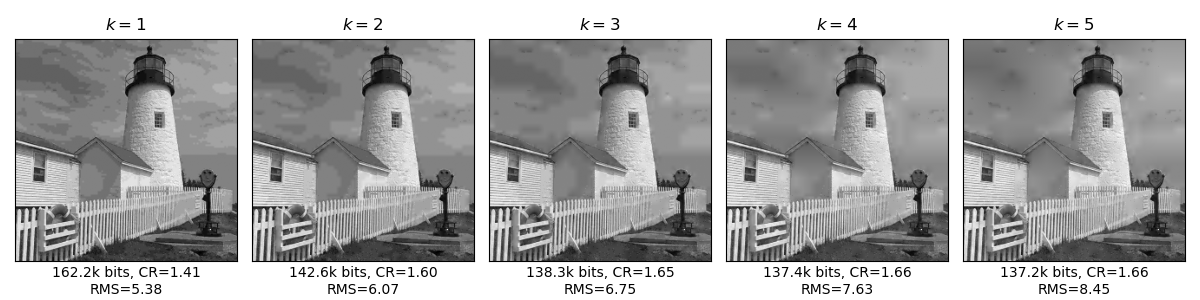

In [26]:
ks = [1, 2, 3, 4, 5]
recons, rms_errors, bits_list = zip(*[pyr_quantize(X, step, k, h) for k in ks])

fig, axs = plt.subplots(1, len(ks), figsize=(12, 3))
for ax, k, Z, err, bits in zip(axs, ks, recons, rms_errors, bits_list):
    plot_image(Z, ax=ax)
    cr = bits_direct / bits
    ax.set(yticks=[], xticks=[],
           title=f'$k={k}$',
           xlabel=f'{bits/1000:.1f}k bits, CR={cr:.2f}\nRMS={err:.2f}')
fig.tight_layout()
fig.savefig('zach/images/recon_vs_k_constant_step.png', dpi=150, bbox_inches='tight')

for k, err, bits in zip(ks, rms_errors, bits_list):
    print(f'k={k}: bits={bits:.0f}, CR={bits_direct/bits:.3f}, RMS = {err:.3f}')

RMS error increases with the pyramid layer!


### Matching step size to direct quantisation


Comparisons of the number of bits with different coding strategies are only valid if they result in _approximately the same image quantisation error_. Write a function which will optimise the step size (resulting in a non-integer value) in the Laplacian scheme until the rms error is the same as for direct quantisation; you will find this optimisation useful for later investigations too.

<div class="alert alert-block alert-danger">
Investigate what step size of the quantisers for the pyramid scheme you need, in order to get approximately the same error as for direct quantisation at a step size of 17.
</div>


In [27]:
#sweep step sizes (in 0.1 intervals) for each pyramid depth, pick the one whose RMS best matches rms_direct
step_grid = np.arange(1, 25, 0.1)


In [28]:
for k in ks:
    errs = np.array([pyr_quantize(X, s, k, h)[1] for s in step_grid])
    best = step_grid[np.argmin(np.abs(errs - rms_direct))]
    print(f'k={k}: matched step ≈ {best:.2f}, RMS = {pyr_quantize(X, best, k, h)[1]:.3f}  (target {rms_direct:.3f})')

k=1: matched step ≈ 15.20, RMS = 4.867  (target 4.861)
k=2: matched step ≈ 13.30, RMS = 4.883  (target 4.861)
k=3: matched step ≈ 11.60, RMS = 4.848  (target 4.861)
k=4: matched step ≈ 10.30, RMS = 4.860  (target 4.861)
k=5: matched step ≈ 9.40, RMS = 4.850  (target 4.861)


### Compression ratio and equal-MSE step sizes


In many of your results from now on you will need to expres the performance of your algorithms in terms of _compression ratio_, which is normally defined as:

$$ \text{Compression Ratio} = \frac{\text{Total bits for reference scheme}}{\text{Total bits for compressed scheme}} $$

Usually the _reference_ scheme is the direct pixel quantisation method with its quantiser adjusted to give the same rms error as the scheme being evaluated (the _compressed_ scheme). For good schemes we try to make the compression ratio as large as possible.

We now investigate the effect of using different step sizes for the different levels of the pyramid. There are many schemes for varying the step sizes between different levels: in this project we shall look at the _equal MSE_ criterion. In the _equal MSE_ scheme, step sizes are chosen such that quantisers in each layer contribute equally to the Mean Squared Error of the reconstructed image. In general the step sizes will depend on the image signal being coded. However this can be achieved approximately by choosing a separate step size for each layer such that:

- A single impulse of that step size will give a filtered pulse in the reconstructed image which has the same energy, whichever layer of the decoder the impulse excites.


### Impulse Response Measurement

Investigate the effect of a single impulse in a particular layer (e.g. **Y0,Y1** etc.) as it appears in the reconstructed image **Z0**. This can be done by first generating a test pyramid image, which is zero everywhere. Then place an impulse (e.g. of amplitude 100) in the centre of one layer, reconstruct the entire pyramid to give **Z0**, then measure the total energy of **Z0**. If this is repeated for each layer, you will have measured how much energy a fixed size impulse at each layer contributes to the decoded image.

We actually want to arrange for the impulse sizes to vary and the energy to stay the same. Therefore the impulse sizes (and hence chosen quantisation steps) we require in each level will be inversely proportional to the square root of the energies measured above. The important result is the _ratio_ of the step sizes between layers. If this ratio is maintained for any overall quantiser scaling, we will get an (approximately) _equal MSE_ scheme.


<div class="alert alert-block alert-danger">
Find new values for the data compression achievable when all schemes (i.e. constant step size or equal MSE, both with varying layer depth) produce the same rms error between the decoded image and the original image. Comment on the differences in compression, visual quality and rms error, and the optimum choice of layer depth in each case.
</div>


In [29]:
# Constant-step CR at equal RMS.
# For each k: sweep step sizes, pick one whose RMS matches rms_direct, compute CR.
cr_const = {}
for k in ks:
    errs = np.array([pyr_quantize(X, s, k, h)[1] for s in step_grid])
    best = step_grid[np.argmin(np.abs(errs - rms_direct))]
    _, rms, bits_pyr = pyr_quantize(X, best, k, h)
    cr_const[k] = bits_direct / bits_pyr
    print(f'k={k}: step≈{best:.2f}, RMS={rms:.3f}, CR={cr_const[k]:.3f}')

k=1: step≈15.20, RMS=4.867, CR=1.330
k=2: step≈13.30, RMS=4.883, CR=1.391
k=3: step≈11.60, RMS=4.848, CR=1.324
k=4: step≈10.30, RMS=4.860, CR=1.248
k=5: step≈9.40, RMS=4.850, CR=1.191


In [30]:
# Equal-MSE step ratios via impulse response.
# A unit impulse placed in subband i, decoded through pykdec, produces a response in Z_0 with
# energy g_i. Quantisation noise in subband i contributes to MSE(Z_0) in proportion to g_i,
# so for equal-MSE we want step_i propor 1 / sqrt(g_i). Only the ratios matter.

def impulse_energy(layer_idx, k, h):
    Ys, Xk = pykenc(np.zeros_like(X), h, k)
    target = Ys[layer_idx] if layer_idx < k else Xk   # picks Y_i or X_k
    r, c = target.shape
    target[r // 2, c // 2] = 1                      # amplitude irrelevant
    Z0 = pykdec(Ys, Xk, h)[-1]
    return np.sum(Z0**2)

#energy ratio control how much to scale later step sizes relative to the first one
def step_ratios(k, h):
    """Per-layer step ratios for equal MSE, normalised so Y_0 step = 1.
    Length k+1, ordered [Y_0, ..., Y_{k-1}, X_k]."""
    e = np.array([impulse_energy(i, k, h) for i in range(k + 1)])
    #normalize, later layers have more energy, so the energy ratios (step ratios) decrease
    return np.sqrt(e[0] / e)

for k in ks:
    print(f'k={k}: step ratios = {np.round(step_ratios(k, h), 3)}')

k=1: step ratios = [1.    0.667]
k=2: step ratios = [1.    0.667 0.364]
k=3: step ratios = [1.    0.667 0.364 0.186]
k=4: step ratios = [1.    0.667 0.364 0.186 0.094]
k=5: step ratios = [1.    0.667 0.364 0.186 0.094 0.047]


In [31]:
# Equal-MSE: sweep overall scale `s` so per-layer steps = s*ratios match rms_direct,
# then report bits and CR. Compare against constant-step results from cell-66.
scale_grid = np.arange(1, 25, 0.1)
cr_eqmse = {}

for k in ks:
    ratios = step_ratios(k, h)
    errs = np.array([pyr_quantize_layered(X, s * ratios, k, h)[1] for s in scale_grid])
    best_s = scale_grid[np.argmin(np.abs(errs - rms_direct))]
    steps  = best_s * ratios
    _, rms, bits_pyr = pyr_quantize_layered(X, steps, k, h)
    cr_eqmse[k] = bits_direct / bits_pyr
    print(f'k={k}: s={best_s:.2f}, steps={np.round(steps, 2)}, RMS={rms:.3f}, CR={cr_eqmse[k]:.3f}')

k=1: s=18.50, steps=[18.5  12.33], RMS=4.848, CR=1.392
k=2: s=18.50, steps=[18.5  12.33  6.73], RMS=4.862, CR=1.541
k=3: s=18.10, steps=[18.1  12.07  6.58  3.37], RMS=4.866, CR=1.549
k=4: s=18.10, steps=[18.1  12.07  6.58  3.37  1.69], RMS=4.868, CR=1.550
k=5: s=18.10, steps=[18.1  12.07  6.58  3.37  1.69  0.85], RMS=4.870, CR=1.549


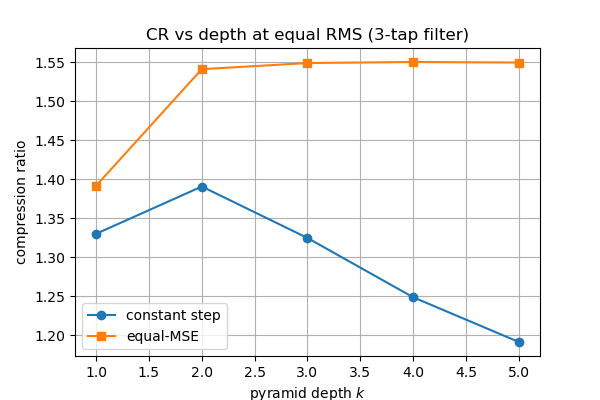

In [32]:
# CR vs pyramid depth at equal RMS (3-tap filter).
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(ks, [cr_const[k] for k in ks], 'o-', label='constant step')
ax.plot(ks, [cr_eqmse[k] for k in ks], 's-', label='equal-MSE')
ax.set(xlabel='pyramid depth $k$', ylabel='compression ratio',
       title='CR vs depth at equal RMS (3-tap filter)')
ax.legend(); ax.grid(True);

## 6.3 Changing the decimation / interpolation filter

It is also worth investigating whether a more complicated decimation / interpolation filter **h** can improve the compression. The z-transfer function of the filter used so far is

$$ h(z) = \left(\frac{1 + z^{-1}}{2}\right)^m $$

where $m = 2$. If $m$ is increased to 4(so the number of taps remains odd), the vector representation of **h** is \[1/16 4/16 6/16 4/16 1/16\]. This filter has a lower cut-off frequency than when $m=2$, so you should find that each interpolated lowpass image in the pyramid is a little more blurred, and there is a little more energy left in each highpass image.

<div class="alert alert-block alert-danger">
Optimise the step sizes for the pyramid with this new filter and determine the new compression performance and visual features.
</div>


In [33]:
# Repeat the previous experiments with a new h here
h = np.array([1, 4, 6, 4, 1]) / 16.0

In [34]:
# 5-tap filter: rerun constant-step + equal-MSE at equal RMS.
# rms_direct and bits_direct unchanged (they only depend on X, not h).
cr_const_5tap, cr_eqmse_5tap = {}, {}
for k in ks:
    # constant step
    errs = np.array([pyr_quantize(X, s, k, h)[1] for s in step_grid])
    best = step_grid[np.argmin(np.abs(errs - rms_direct))]
    cr_const_5tap[k] = bits_direct / pyr_quantize(X, best, k, h)[2]
    # equal-MSE
    ratios = step_ratios(k, h)
    errs = np.array([pyr_quantize_layered(X, s * ratios, k, h)[1] for s in scale_grid])
    best_s = scale_grid[np.argmin(np.abs(errs - rms_direct))]
    cr_eqmse_5tap[k] = bits_direct / pyr_quantize_layered(X, best_s * ratios, k, h)[2]
    print(f'k={k}: const CR={cr_const_5tap[k]:.3f},  equal-MSE CR={cr_eqmse_5tap[k]:.3f}')

k=1: const CR=1.274,  equal-MSE CR=1.290
k=2: const CR=1.328,  equal-MSE CR=1.410
k=3: const CR=1.286,  equal-MSE CR=1.422
k=4: const CR=1.211,  equal-MSE CR=1.417
k=5: const CR=1.189,  equal-MSE CR=1.421


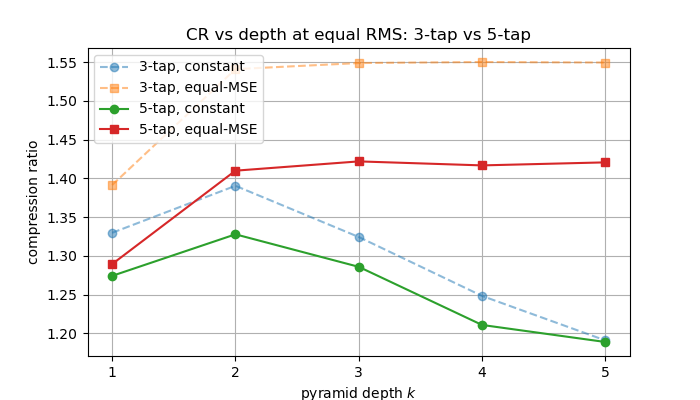

In [35]:
# Compare 3-tap vs 5-tap filter.
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ks, [cr_const[k]      for k in ks], 'o--', alpha=0.5, label='3-tap, constant')
ax.plot(ks, [cr_eqmse[k]      for k in ks], 's--', alpha=0.5, label='3-tap, equal-MSE')
ax.plot(ks, [cr_const_5tap[k] for k in ks], 'o-',             label='5-tap, constant')
ax.plot(ks, [cr_eqmse_5tap[k] for k in ks], 's-',             label='5-tap, equal-MSE')
ax.set(xlabel='pyramid depth $k$', ylabel='compression ratio',
       title='CR vs depth at equal RMS: 3-tap vs 5-tap',
       xticks=ks)
ax.legend(); ax.grid(True);
fig.savefig('zach/images/cr_vs_depth.png', dpi=150, bbox_inches='tight')

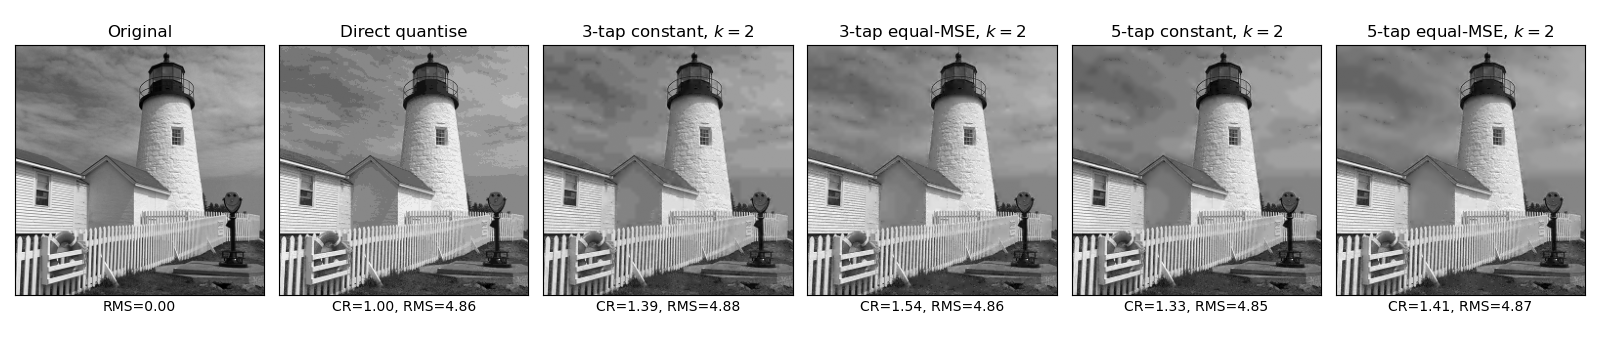

In [36]:
# Visual comparison: original + direct quantise + all 4 pyramid schemes at k=2.
k_vis = 2
h_3 = 0.25 * np.array([1, 2, 1])
h_5 = np.array([1, 4, 6, 4, 1]) / 16.0

def best_const(h_f, k):
    errs = np.array([pyr_quantize(X, s, k, h_f)[1] for s in step_grid])
    best = step_grid[np.argmin(np.abs(errs - rms_direct))]
    return pyr_quantize(X, best, k, h_f)            # Z0_q, rms, bits

def best_eqmse(h_f, k):
    ratios = step_ratios(k, h_f)
    errs = np.array([pyr_quantize_layered(X, s * ratios, k, h_f)[1] for s in scale_grid])
    best_s = scale_grid[np.argmin(np.abs(errs - rms_direct))]
    return pyr_quantize_layered(X, best_s * ratios, k, h_f)

results = [
    ('3-tap constant',  *best_const(h_3, k_vis)),
    ('3-tap equal-MSE', *best_eqmse(h_3, k_vis)),
    ('5-tap constant',  *best_const(h_5, k_vis)),
    ('5-tap equal-MSE', *best_eqmse(h_5, k_vis)),
]

fig, axs = plt.subplots(1, 6, figsize=(16, 3.4))
plot_image(X, ax=axs[0])
axs[0].set(title='Original', xticks=[], yticks=[], xlabel='RMS=0.00')
plot_image(X_q, ax=axs[1])
axs[1].set(title='Direct quantise', xticks=[], yticks=[],
           xlabel=f'CR=1.00, RMS={rms_direct:.2f}')
for ax, (label, Z, rms, bits) in zip(axs[2:], results):
    cr = bits_direct / bits
    plot_image(Z, ax=ax)
    ax.set(title=f'{label}, $k={k_vis}$',
           xticks=[], yticks=[],
           xlabel=f'CR={cr:.2f}, RMS={rms:.2f}')
fig.tight_layout()
fig.savefig('zach/images/visual_compare_k2_all_methods.png', dpi=150, bbox_inches='tight')

## 6.4 Why does the 5-tap filter give worse compression?

A natural first guess is that the 5-tap's lower cutoff **discards** more of the image's spectral energy — a hard-cutoff argument. We test this by comparing the two filters' frequency responses against the image's radial power spectrum.


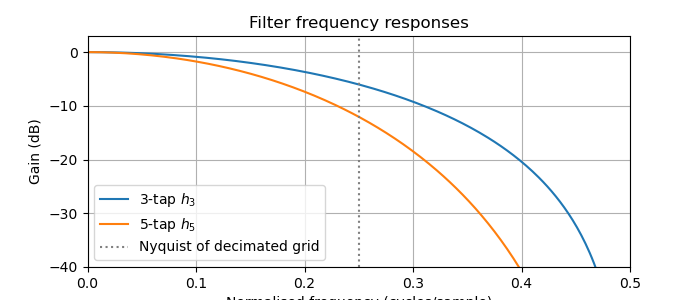

In [37]:
h_3 = 0.25 * np.array([1, 2, 1])
h_5 = np.array([1, 4, 6, 4, 1]) / 16.0

N = 512
freqs = np.arange(N) / N

def freq_response(h, N):
    padded = np.zeros(N)
    m = len(h)
    padded[:m] = h
    padded = np.roll(padded, -(m // 2))
    return np.abs(np.fft.fft(padded))

H3 = freq_response(h_3, N)
H5 = freq_response(h_5, N)

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(freqs[:N//2], 20*np.log10(H3[:N//2] + 1e-12), label='3-tap $h_3$')
ax.plot(freqs[:N//2], 20*np.log10(H5[:N//2] + 1e-12), label='5-tap $h_5$')
ax.axvline(0.25, color='gray', ls=':', label='Nyquist of decimated grid')
ax.set(xlabel='Normalised frequency (cycles/sample)', ylabel='Gain (dB)',
       title='Filter frequency responses', xlim=(0, 0.5), ylim=(-40, 3))
ax.legend(); ax.grid(True)

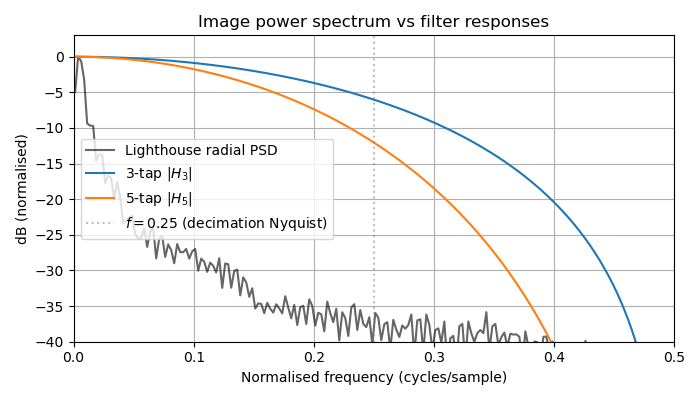

In [38]:
F = np.fft.fft2(X)
P = np.abs(np.fft.fftshift(F))**2
rows, cols = P.shape
cy, cx = rows // 2, cols // 2
y_idx, x_idx = np.ogrid[:rows, :cols]
r = np.sqrt((y_idx - cy)**2 + (x_idx - cx)**2)
r_norm = r / max(rows, cols)

n_bins = 200
r_edges = np.linspace(0, 0.5, n_bins + 1)
r_centres = 0.5 * (r_edges[:-1] + r_edges[1:])
radial_power = np.zeros(n_bins)
for i in range(n_bins):
    mask = (r_norm >= r_edges[i]) & (r_norm < r_edges[i+1])
    if mask.any():
        radial_power[i] = P[mask].mean()

radial_dB = 10 * np.log10(radial_power + 1e-12)
radial_dB -= radial_dB.max()

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(r_centres, radial_dB, 'k-', alpha=0.6, label='Lighthouse radial PSD')
ax.plot(freqs[:N//2], 20*np.log10(H3[:N//2] + 1e-12), label='3-tap $|H_3|$')
ax.plot(freqs[:N//2], 20*np.log10(H5[:N//2] + 1e-12), label='5-tap $|H_5|$')
ax.axvline(0.25, color='gray', ls=':', alpha=0.5, label='$f=0.25$ (decimation Nyquist)')
ax.set(xlabel='Normalised frequency (cycles/sample)', ylabel='dB (normalised)',
       title='Image power spectrum vs filter responses',
       xlim=(0, 0.5), ylim=(-40, 3))
ax.legend(); ax.grid(True)
fig.tight_layout()
fig.savefig('zach/images/fft_filter_vs_spectrum.png', dpi=150, bbox_inches='tight')

In [39]:
def cutoff_3dB(H, freqs):
    dB = 20*np.log10(H + 1e-12)
    idx = np.where(dB[:len(freqs)] <= -3)[0]
    return freqs[idx[0]] if len(idx) else freqs[-1]

f3 = cutoff_3dB(H3, freqs[:N//2])
f5 = cutoff_3dB(H5, freqs[:N//2])
print(f'3-tap -3dB cutoff: {f3:.4f} cycles/sample')
print(f'5-tap -3dB cutoff: {f5:.4f} cycles/sample')

total_energy = radial_power.sum()
band_mask = (r_centres >= f5) & (r_centres < f3)
band_energy = radial_power[band_mask].sum()
print(f'\nImage energy in [{f5:.3f}, {f3:.3f}): {band_energy/total_energy*100:.1f}% of total')
print('This is the energy the 5-tap discards but the 3-tap keeps in X_{k+1}.')

3-tap -3dB cutoff: 0.1836 cycles/sample
5-tap -3dB cutoff: 0.1309 cycles/sample

Image energy in [0.131, 0.184): 0.3% of total
This is the energy the 5-tap discards but the 3-tap keeps in X_{k+1}.


Only 0.3% of the image energy sits in the transition band between the two cutoffs — the hard-cutoff argument fails. The real mechanism is the **gain shape within the passband**. Most of the image's spectral energy is concentrated at low frequencies, and both filters pass these frequencies — but the 3-tap has higher gain (closer to 0 dB) across this range. In the interpolation step $\hat{X}_k = (2h)*U(X_{k+1})$, the 3-tap therefore preserves and amplifies the dominant low-frequency components more faithfully. The 5-tap rolls off earlier and more steeply, so even at frequencies well within both passbands, it attenuates them more. This makes the 5-tap's prediction $\hat{X}_k$ systematically worse, leaving more energy in the residual $Y_k = X_k - \hat{X}_k$, which at the same quantisation step requires more bits.


In [40]:
h_3 = 0.25 * np.array([1, 2, 1])
h_5 = np.array([1, 4, 6, 4, 1]) / 16.0

print('Per-layer residual energy E[Y_k] and entropy (bpp at step=17):')
print(f'{"layer":<8} {"3-tap energy":>14} {"5-tap energy":>14} {"3-tap bpp":>10} {"5-tap bpp":>10}')
for k in range(1, 6):
    Ys3, Xk3 = pykenc(X, h_3, k)
    Ys5, Xk5 = pykenc(X, h_5, k)
    for i in range(k):
        e3 = np.sum(Ys3[i]**2)
        e5 = np.sum(Ys5[i]**2)
        b3 = bpp(quantise(Ys3[i], 17))
        b5 = bpp(quantise(Ys5[i], 17))
        if k == 4:
            print(f'Y_{i:<6} {e3:>14.0f} {e5:>14.0f} {b3:>10.3f} {b5:>10.3f}')
    if k == 4:
        e3 = np.sum(Xk3**2); e5 = np.sum(Xk5**2)
        b3 = bpp(quantise(Xk3, 17)); b5 = bpp(quantise(Xk5, 17))
        print(f'X_{k:<6} {e3:>14.0f} {e5:>14.0f} {b3:>10.3f} {b5:>10.3f}')
        total3 = sum(bpp(quantise(Y, 17)) * Y.size for Y in Ys3) + bpp(quantise(Xk3, 17)) * Xk3.size
        total5 = sum(bpp(quantise(Y, 17)) * Y.size for Y in Ys5) + bpp(quantise(Xk5, 17)) * Xk5.size
        print(f'\nTotal bits at k=4, step=17:  3-tap={total3:.0f},  5-tap={total5:.0f}')

Per-layer residual energy E[Y_k] and entropy (bpp at step=17):
layer      3-tap energy   5-tap energy  3-tap bpp  5-tap bpp
Y_0            18689489       24593020      1.621      1.822
Y_1             3030320        2956937      1.391      1.408
Y_2              689184         622404      1.455      1.496
Y_3              182761         197298      1.578      1.754
X_4              315517         271794      3.016      2.890

Total bits at k=4, step=17:  3-tap=137353,  5-tap=151139


Residual energy ratio (5-tap / 3-tap): 1.32x


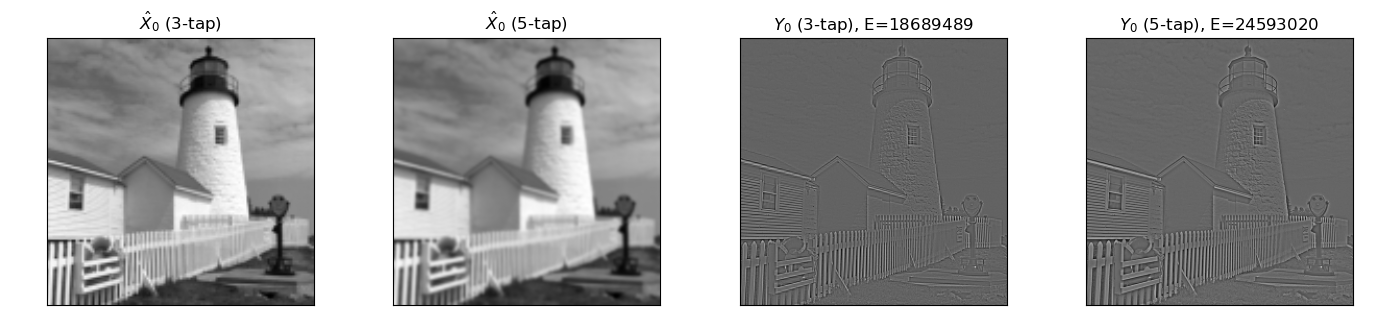

In [41]:
X1_3 = rowdec(rowdec(X, h_3).T, h_3).T
X0_hat_3 = rowint(rowint(X1_3, 2*h_3).T, 2*h_3).T

X1_5 = rowdec(rowdec(X, h_5).T, h_5).T
X0_hat_5 = rowint(rowint(X1_5, 2*h_5).T, 2*h_5).T

Y0_3 = X - X0_hat_3
Y0_5 = X - X0_hat_5

fig, axs = plt.subplots(1, 4, figsize=(14, 3.2))
for ax, img, title in zip(axs, [X0_hat_3, X0_hat_5, Y0_3, Y0_5],
    ['$\\hat{X}_0$ (3-tap)', '$\\hat{X}_0$ (5-tap)',
     f'$Y_0$ (3-tap), E={np.sum(Y0_3**2):.0f}',
     f'$Y_0$ (5-tap), E={np.sum(Y0_5**2):.0f}']):
    plot_image(img, ax=ax)
    ax.set(xticks=[], yticks=[], title=title)
fig.tight_layout()
fig.savefig('zach/images/prediction_compare.png', dpi=150, bbox_inches='tight')
print(f'Residual energy ratio (5-tap / 3-tap): {np.sum(Y0_5**2) / np.sum(Y0_3**2):.2f}x')

The residual energy table and prediction images confirm the gain-shape mechanism: the 5-tap's steeper roll-off within the passband attenuates the dominant low-frequency components more, producing a worse prediction $\hat{X}_k$ and leaving substantially more energy in $Y_0$ (and every subsequent $Y_k$). At the same quantisation step this means more non-zero symbols and higher entropy per pixel, requiring more bits. The effect compounds across layers, explaining the consistently lower CR across all depths and both quantisation schemes.


# First Interim Report

Discuss and explain your results, gathered so far, in your first interim report. Try to answer the questions posed in the above test. Be brief where things are straightforward, but pay more attention to detail in areas where you think something interesting is happening. Write this as a standalone report, not as a series of bullet points answering the questions posed.
